# Ide 1: Skenario Prediktif & Time Series

**Fokus:** Deep Learning dan Time Series Data Mining  
**Topik:** Analisis climate change dan perubahan tutupan lahan  
**Tujuan:** Memprediksi anomali suhu (`GT`) tahun ke-`t` menggunakan riwayat tutupan lahan (`LC/RL`) dan emisi (`ET`) dari tahun `t-5` sampai `t-1`.

Alur logika penelitian:

`perubahan tutupan lahan -> emisi -> akumulasi dampak -> anomali suhu beberapa tahun berikutnya`

Notebook ini dapat digunakan sebagai dasar implementasi **early warning system**: jika suatu negara memiliki tren deforestasi, ekspansi agrikultur, atau kenaikan emisi tertentu, model memproyeksikan potensi anomali suhu pada tahun mendatang.

## 1. Desain Eksperimen

- **Unit observasi:** negara-tahun (`Area`, `Year`).
- **Target:** `Temperature_Change`, yaitu anomali suhu tahunan.
- **Fitur utama:** seluruh atribut tutupan lahan dan emisi yang tersedia di dataset gabungan FAOSTAT.
- **Representasi time series:** setiap sampel berisi urutan 5 tahun historis untuk satu negara.
- **Model utama:** LSTM atau GRU untuk menangkap efek lagged antara perubahan lahan/emisi dan suhu.
- **Baseline pembanding:** regresi linear pada fitur agregat historis agar performa deep learning tidak dinilai tanpa pembanding.
- **Skema validasi:** split berdasarkan tahun target supaya data masa depan tidak bocor ke training set.

## 2. Import Library

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, Input
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    tf.random.set_seed(RANDOM_STATE)
    TENSORFLOW_AVAILABLE = True
    print('TensorFlow tersedia:', tf.__version__)
except Exception as exc:
    TENSORFLOW_AVAILABLE = False
    print('TensorFlow belum tersedia. Cell model LSTM/GRU akan dilewati.')
    print('Detail:', exc)

TensorFlow belum tersedia. Cell model LSTM/GRU akan dilewati.
Detail: No module named 'tensorflow'


## 3. Load Dataset

Default notebook menggunakan dataset ASEAN karena notebook eksplorasi sebelumnya juga berfokus pada Asia Tenggara. Jika ingin memakai seluruh negara tropis atau seluruh dunia, ubah nilai `DATA_PATH`.

In [2]:
DATA_PATH = 'Merged_Climate_LandCover_Data_ASEAN.csv'

if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Merged_Climate_LandCover_Data_FullyTropical.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Merged_Climate_LandCover_Data.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw['Year'] = df_raw['Year'].astype(int)
df_raw = df_raw.sort_values(['Area', 'Year']).reset_index(drop=True)

print('Dataset:', DATA_PATH)
print('Shape:', df_raw.shape)
print('Rentang tahun:', df_raw['Year'].min(), '-', df_raw['Year'].max())
print('Jumlah area:', df_raw['Area'].nunique())
df_raw.head()

Dataset: Merged_Climate_LandCover_Data_ASEAN.csv
Shape: (310, 59)
Rentang tahun: 1992 - 2022
Jumlah area: 10


,Area,Year,Temperature_Change,Artificial surfaces (including urban and associated areas),Grassland,Herbaceous crops,Inland water bodies,Mangroves,Permanent snow and glaciers,Shrub-covered areas,"Shrubs and/or herbaceous vegetation, aquatic or regularly flooded",Sparsely natural vegetated areas,Terrestrial barren land,Tree-covered areas,Woody crops,...,International bunkers,LULUCF,Land-use change,Manure Management,Manure applied to Soils,Manure left on Pasture,Net Forest conversion,On-farm energy use,Other,Pesticides Manufacturing,Pre- and post-production,Rice Cultivation,Savanna fires,Synthetic Fertilizers,Waste
0,Brunei Darussalam,1992,0.4540,1.1000,10.5300,27.8000,16.5600,19.3000,0.0000,7.6400,0.0000,0.2300,0.0000,498.6800,27.8000,...,NaN,475.6081,368.8079,3.6721,4.5580,7.1815,844.6295,10.1803,14.8135,1.6735,156.6899,6.8068,0.0689,0.0000,37.7747
1,Brunei Darussalam,1993,0.2670,1.1000,10.5300,27.8000,16.5600,19.3000,0.0000,7.6400,0.0000,0.2300,0.0000,498.6800,27.8000,...,NaN,475.6081,368.8079,3.6514,4.9820,7.8440,844.6295,12.6989,15.8205,2.0828,163.8752,7.2940,0.0689,0.0000,39.0630
2,Brunei Darussalam,1994,0.4570,1.1100,10.5300,27.8000,16.5600,19.2900,0.0000,7.6400,0.0000,0.2300,0.0000,498.6800,27.8000,...,NaN,475.6081,368.8079,3.6138,5.0085,7.8705,844.6295,14.0422,14.2040,2.4780,170.3845,7.2940,0.0689,0.0000,40.5933
3,Brunei Darussalam,1995,0.5010,1.1600,10.6200,28.2100,15.9900,19.3900,0.0000,7.6900,0.0000,0.2300,0.0000,498.1600,28.2100,...,NaN,480.5386,368.8079,3.4682,5.1145,8.0825,844.6295,0.0000,15.1315,2.7790,169.1747,4.8608,0.0689,0.0000,41.9647
4,Brunei Darussalam,1996,0.4140,1.2000,10.6100,28.1300,15.9000,19.3800,0.0000,7.6800,0.0000,0.2300,0.0000,498.3800,28.1300,...,NaN,456.4086,344.6779,3.5417,5.1410,8.1090,844.6295,0.0000,17.2515,2.9933,177.4201,4.3764,0.1603,0.0000,43.5583


## 4. Identifikasi Target dan Fitur

In [3]:
TARGET = 'Temperature_Change'
ID_COLS = ['Area', 'Year']

land_cover_cols = [
    'Artificial surfaces (including urban and associated areas)',
    'Grassland',
    'Herbaceous crops',
    'Inland water bodies',
    'Mangroves',
    'Permanent snow and glaciers',
    'Shrub-covered areas',
    'Shrubs and/or herbaceous vegetation, aquatic or regularly flooded',
    'Sparsely natural vegetated areas',
    'Terrestrial barren land',
    'Tree-covered areas',
    'Woody crops',
]
land_cover_cols = [c for c in land_cover_cols if c in df_raw.columns]

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
emission_cols = [c for c in numeric_cols if c not in ID_COLS + [TARGET] + land_cover_cols]

print('Jumlah fitur tutupan lahan:', len(land_cover_cols))
print('Jumlah fitur emisi:', len(emission_cols))
print('Contoh fitur emisi:', emission_cols[:10])

Jumlah fitur tutupan lahan: 12
Jumlah fitur emisi: 44
Contoh fitur emisi: ['AFOLU', 'Agricultural Soils', 'Agrifood Systems Waste Disposal', 'Agrifood systems', 'All sectors with LULUCF', 'All sectors without LULUCF', 'Burning - Crop residues', 'Crop Residues', 'Drained organic soils', 'Drained organic soils (CO2)']


## 5. Eksplorasi Singkat Time Series

,Year,mean_temp_change,median_temp_change,total_tree_area,total_herbaceous_crops,total_afolu
0,1992,0.2906,0.3430,229597.2800,92517.6900,819934.1110
1,1993,0.2581,0.2730,229602.5100,91820.5700,822836.3039
2,1994,0.3769,0.3590,229607.0700,90127.7200,828150.7277
3,1995,0.5138,0.5400,228362.8900,90129.4600,835734.7909
4,1996,0.2824,0.3360,228761.2000,90395.0300,763241.6048


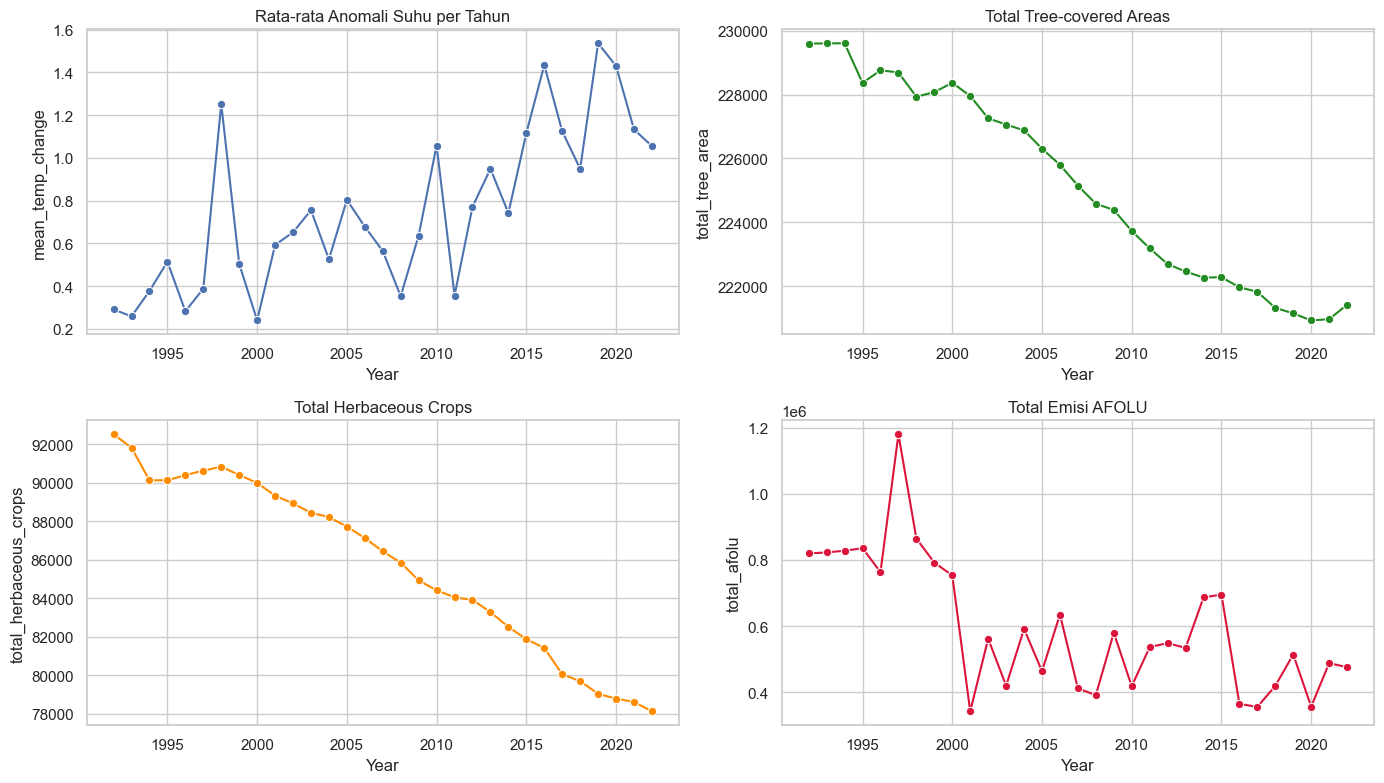

In [4]:
summary = df_raw.groupby('Year').agg(
    mean_temp_change=(TARGET, 'mean'),
    median_temp_change=(TARGET, 'median'),
    total_tree_area=('Tree-covered areas', 'sum') if 'Tree-covered areas' in df_raw.columns else (TARGET, 'size'),
    total_herbaceous_crops=('Herbaceous crops', 'sum') if 'Herbaceous crops' in df_raw.columns else (TARGET, 'size'),
    total_afolu=('AFOLU', 'sum') if 'AFOLU' in df_raw.columns else (TARGET, 'size'),
).reset_index()

display(summary.head())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.lineplot(data=summary, x='Year', y='mean_temp_change', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Rata-rata Anomali Suhu per Tahun')

if 'Tree-covered areas' in df_raw.columns:
    sns.lineplot(data=summary, x='Year', y='total_tree_area', marker='o', ax=axes[0, 1], color='forestgreen')
    axes[0, 1].set_title('Total Tree-covered Areas')

if 'Herbaceous crops' in df_raw.columns:
    sns.lineplot(data=summary, x='Year', y='total_herbaceous_crops', marker='o', ax=axes[1, 0], color='darkorange')
    axes[1, 0].set_title('Total Herbaceous Crops')

if 'AFOLU' in df_raw.columns:
    sns.lineplot(data=summary, x='Year', y='total_afolu', marker='o', ax=axes[1, 1], color='crimson')
    axes[1, 1].set_title('Total Emisi AFOLU')

for ax in axes.ravel():
    ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

## 6. Praproses Data

Tahapan ini mencakup:

- penanganan missing value,
- transformasi fitur perubahan tahunan,
- normalisasi/standardisasi fitur,
- seleksi fitur numerik untuk model time series.

In [5]:
df = df_raw.copy()

missing_rate = df.isna().mean().sort_values(ascending=False)
display(missing_rate[missing_rate > 0].head(20).to_frame('missing_rate'))

# Interpolasi dilakukan per negara agar pola time series tidak tercampur antarnegara.
feature_cols_base = land_cover_cols + emission_cols

# Drop fitur yang seluruh nilainya kosong. Model Ridge masih bisa memakai imputer,
# tetapi LSTM/GRU tidak boleh menerima NaN di input tensor.
all_missing_cols = [c for c in feature_cols_base if df[c].isna().all()]
if all_missing_cols:
    print('Fitur dihapus karena seluruh nilainya kosong:', all_missing_cols)
feature_cols_base = [c for c in feature_cols_base if c not in all_missing_cols]
for col in feature_cols_base + [TARGET]:
    if col in df.columns:
        df[col] = df.groupby('Area')[col].transform(lambda s: s.interpolate(limit_direction='both'))
        df[col] = df[col].fillna(df[col].median())

# Transformasi perubahan tahunan untuk menangkap deforestasi/ekspansi agrikultur.
for col in land_cover_cols:
    df[f'delta_{col}'] = df.groupby('Area')[col].diff().fillna(0)

if 'Tree-covered areas' in df.columns:
    df['tree_area_loss'] = (-df['delta_Tree-covered areas']).clip(lower=0)
if 'Herbaceous crops' in df.columns:
    df['crop_expansion'] = df['delta_Herbaceous crops'].clip(lower=0)
if 'Woody crops' in df.columns:
    df['woody_crop_expansion'] = df['delta_Woody crops'].clip(lower=0)
if 'Artificial surfaces (including urban and associated areas)' in df.columns:
    df['urban_expansion'] = df['delta_Artificial surfaces (including urban and associated areas)'].clip(lower=0)

derived_cols = [c for c in df.columns if c.startswith('delta_') or c in [
    'tree_area_loss', 'crop_expansion', 'woody_crop_expansion', 'urban_expansion'
]]

feature_cols = feature_cols_base + derived_cols
feature_cols = [c for c in feature_cols if c in df.columns and c != TARGET]

print('Jumlah fitur final:', len(feature_cols))
df[['Area', 'Year', TARGET] + feature_cols[:8]].head()

,missing_rate
International bunkers,1.0000
Food Processing,0.5000
Fertilizers Manufacturing,0.4065
Food Packaging,0.2000
Temperature_Change,0.1000
Rice Cultivation,0.1000
Pesticides Manufacturing,0.1000
Crop Residues,0.1000
Burning - Crop residues,0.0968
On-farm energy use,0.0613


Jumlah fitur final: 72


,Area,Year,Temperature_Change,Artificial surfaces (including urban and associated areas),Grassland,Herbaceous crops,Inland water bodies,Mangroves,Permanent snow and glaciers,Shrub-covered areas,"Shrubs and/or herbaceous vegetation, aquatic or regularly flooded"
0,Brunei Darussalam,1992,0.4540,1.1000,10.5300,27.8000,16.5600,19.3000,0.0000,7.6400,0.0000
1,Brunei Darussalam,1993,0.2670,1.1000,10.5300,27.8000,16.5600,19.3000,0.0000,7.6400,0.0000
2,Brunei Darussalam,1994,0.4570,1.1100,10.5300,27.8000,16.5600,19.2900,0.0000,7.6400,0.0000
3,Brunei Darussalam,1995,0.5010,1.1600,10.6200,28.2100,15.9900,19.3900,0.0000,7.6900,0.0000
4,Brunei Darussalam,1996,0.4140,1.2000,10.6100,28.1300,15.9000,19.3800,0.0000,7.6800,0.0000


## 7. Membuat Window Time Series `t-5` sampai `t-1`

Untuk setiap negara dan setiap tahun target `t`, input model adalah data lima tahun sebelumnya. Contoh: target 2020 memakai fitur tahun 2015, 2016, 2017, 2018, dan 2019.

In [6]:
SEQ_LEN = 5

def make_sequences(data, features, target, seq_len=5):
    X, y, meta = [], [], []
    for area, group in data.sort_values(['Area', 'Year']).groupby('Area'):
        group = group.sort_values('Year').reset_index(drop=True)
        values = group[features].to_numpy(dtype='float32')
        targets = group[target].to_numpy(dtype='float32')
        years = group['Year'].to_numpy()

        for i in range(seq_len, len(group)):
            if np.isnan(targets[i]):
                continue
            X.append(values[i-seq_len:i])
            y.append(targets[i])
            meta.append({'Area': area, 'target_year': int(years[i])})

    return np.array(X, dtype='float32'), np.array(y, dtype='float32'), pd.DataFrame(meta)

X, y, meta = make_sequences(df, feature_cols, TARGET, SEQ_LEN)

print('X shape:', X.shape)
print('y shape:', y.shape)
display(meta.head())

X shape: (260, 5, 72)
y shape: (260,)


,Area,target_year
0,Brunei Darussalam,1997
1,Brunei Darussalam,1998
2,Brunei Darussalam,1999
3,Brunei Darussalam,2000
4,Brunei Darussalam,2001


## 8. Train-Validation-Test Split Berdasarkan Tahun Target

Split berdasarkan tahun target penting untuk mencegah data leakage. Model dilatih pada masa lalu, divalidasi pada tahun berikutnya, dan diuji pada tahun paling baru.

In [7]:
train_mask = meta['target_year'] <= 2016
val_mask = (meta['target_year'] >= 2017) & (meta['target_year'] <= 2019)
test_mask = meta['target_year'] >= 2020

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
meta_test = meta[test_mask].reset_index(drop=True)

if np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any():
    raise ValueError('Masih ada NaN pada fitur sequence. Cek kembali preprocessing/imputasi fitur.')
if np.isnan(y_train).any() or np.isnan(y_val).any() or np.isnan(y_test).any():
    raise ValueError('Masih ada NaN pada target. Cek kembali preprocessing target.')

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

scaler = StandardScaler()
n_features = X_train.shape[-1]

X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print('Standardisasi selesai.')

Train: (200, 5, 72) (200,)
Validation: (30, 5, 72) (30,)
Test: (30, 5, 72) (30,)
Standardisasi selesai.


## 9. Baseline: Ridge Regression

Baseline menggunakan ringkasan statistik dari window 5 tahun: nilai rata-rata, nilai terakhir, dan tren sederhana. Ini menjadi pembanding apakah LSTM/GRU benar-benar memberi peningkatan performa.

In [8]:
def flatten_window_features(X_window):
    mean_values = X_window.mean(axis=1)
    last_values = X_window[:, -1, :]
    trend_values = X_window[:, -1, :] - X_window[:, 0, :]
    return np.concatenate([mean_values, last_values, trend_values], axis=1)

X_train_flat = flatten_window_features(X_train)
X_val_flat = flatten_window_features(X_val)
X_test_flat = flatten_window_features(X_test)

baseline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0)),
])
baseline.fit(X_train_flat, y_train)

baseline_val_pred = baseline.predict(X_val_flat)
baseline_test_pred = baseline.predict(X_test_flat)

def regression_metrics(y_true, y_pred, label):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = [
    regression_metrics(y_val, baseline_val_pred, 'Ridge Validation'),
    regression_metrics(y_test, baseline_test_pred, 'Ridge Test'),
]
pd.DataFrame(results)

TypeError: got an unexpected keyword argument 'squared'

## 10. Model Deep Learning: LSTM atau GRU

Gunakan `MODEL_TYPE = 'LSTM'` atau `MODEL_TYPE = 'GRU'`. LSTM cocok ketika pola lag lebih panjang dan kompleks, sementara GRU biasanya lebih ringan dan cepat dilatih.

In [ ]:
MODEL_TYPE = 'LSTM'  # pilihan: 'LSTM' atau 'GRU'
EPOCHS = 120
BATCH_SIZE = 16

history = None
dl_test_pred = None

if TENSORFLOW_AVAILABLE:
    recurrent_layer = LSTM if MODEL_TYPE.upper() == 'LSTM' else GRU

    model = Sequential([
        Input(shape=(SEQ_LEN, n_features)),
        recurrent_layer(64, return_sequences=False),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-5),
    ]

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    dl_val_pred = model.predict(X_val_scaled).ravel()
    dl_test_pred = model.predict(X_test_scaled).ravel()

    results.extend([
        regression_metrics(y_val, dl_val_pred, f'{MODEL_TYPE} Validation'),
        regression_metrics(y_test, dl_test_pred, f'{MODEL_TYPE} Test'),
    ])
else:
    print('Install TensorFlow untuk menjalankan model deep learning, contoh: pip install tensorflow')

pd.DataFrame(results)

## 11. Visualisasi Training dan Evaluasi

In [ ]:
if history is not None:
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.lineplot(data=hist[['loss', 'val_loss']], ax=axes[0])
    axes[0].set_title('Loss MSE')
    axes[0].set_xlabel('Epoch')
    sns.lineplot(data=hist[['mae', 'val_mae']], ax=axes[1])
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada history training untuk divisualisasikan.')

In [ ]:
plot_pred = dl_test_pred if dl_test_pred is not None else baseline_test_pred
plot_label = MODEL_TYPE if dl_test_pred is not None else 'Ridge Baseline'

pred_df = meta_test.copy()
pred_df['actual'] = y_test
pred_df['predicted'] = plot_pred
pred_df['error'] = pred_df['predicted'] - pred_df['actual']

display(pred_df.sort_values('target_year').head(20))

plt.figure(figsize=(6, 6))
sns.scatterplot(data=pred_df, x='actual', y='predicted', hue='target_year', palette='viridis')
min_val = min(pred_df['actual'].min(), pred_df['predicted'].min())
max_val = max(pred_df['actual'].max(), pred_df['predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title(f'Aktual vs Prediksi Test Set - {plot_label}')
plt.xlabel('Aktual Temperature Change')
plt.ylabel('Prediksi Temperature Change')
plt.tight_layout()
plt.show()

## 12. Analisis Prediksi per Negara

In [ ]:
country_to_plot = pred_df['Area'].value_counts().index[0]

country_pred = pred_df[pred_df['Area'] == country_to_plot].sort_values('target_year')
plt.figure(figsize=(10, 4))
plt.plot(country_pred['target_year'], country_pred['actual'], marker='o', label='Aktual')
plt.plot(country_pred['target_year'], country_pred['predicted'], marker='o', label='Prediksi')
plt.title(f'Prediksi Anomali Suhu: {country_to_plot}')
plt.xlabel('Tahun Target')
plt.ylabel('Temperature Change')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Simulasi Early Warning System

Cell ini membuat skenario sederhana untuk satu negara. Riwayat 5 tahun terakhir dimodifikasi dengan asumsi:

- `Tree-covered areas` turun sekian persen per tahun,
- `Herbaceous crops` naik sekian persen per tahun,
- emisi kunci seperti `AFOLU`, `LULUCF`, dan `Net Forest conversion` naik sekian persen per tahun.

Outputnya adalah prediksi anomali suhu berdasarkan skenario tersebut.

In [ ]:
def predict_scenario(area, annual_tree_loss_pct=1.0, annual_crop_growth_pct=1.0, annual_emission_growth_pct=2.0):
    if area not in df['Area'].unique():
        raise ValueError(f'Area tidak ditemukan: {area}')

    history_df = df[df['Area'] == area].sort_values('Year').tail(SEQ_LEN).copy()
    if len(history_df) < SEQ_LEN:
        raise ValueError(f'Riwayat {area} kurang dari {SEQ_LEN} tahun.')

    scenario_df = history_df.copy()

    for step, idx in enumerate(scenario_df.index, start=1):
        if 'Tree-covered areas' in scenario_df.columns:
            scenario_df.loc[idx, 'Tree-covered areas'] *= (1 - annual_tree_loss_pct / 100) ** step
        if 'Herbaceous crops' in scenario_df.columns:
            scenario_df.loc[idx, 'Herbaceous crops'] *= (1 + annual_crop_growth_pct / 100) ** step
        for col in ['AFOLU', 'LULUCF', 'Net Forest conversion', 'Land-use change']:
            if col in scenario_df.columns:
                scenario_df.loc[idx, col] *= (1 + annual_emission_growth_pct / 100) ** step

    for col in land_cover_cols:
        delta_col = f'delta_{col}'
        if delta_col in scenario_df.columns:
            scenario_df[delta_col] = scenario_df[col].diff().fillna(0)

    if 'Tree-covered areas' in scenario_df.columns and 'tree_area_loss' in scenario_df.columns:
        scenario_df['tree_area_loss'] = (-scenario_df['delta_Tree-covered areas']).clip(lower=0)
    if 'Herbaceous crops' in scenario_df.columns and 'crop_expansion' in scenario_df.columns:
        scenario_df['crop_expansion'] = scenario_df['delta_Herbaceous crops'].clip(lower=0)
    if 'Woody crops' in scenario_df.columns and 'woody_crop_expansion' in scenario_df.columns:
        scenario_df['woody_crop_expansion'] = scenario_df['delta_Woody crops'].clip(lower=0)
    urban_delta = 'delta_Artificial surfaces (including urban and associated areas)'
    if urban_delta in scenario_df.columns and 'urban_expansion' in scenario_df.columns:
        scenario_df['urban_expansion'] = scenario_df[urban_delta].clip(lower=0)

    scenario_X = scenario_df[feature_cols].to_numpy(dtype='float32')[None, :, :]

    if dl_test_pred is not None:
        scenario_scaled = scaler.transform(scenario_X.reshape(-1, n_features)).reshape(scenario_X.shape)
        prediction = float(model.predict(scenario_scaled, verbose=0).ravel()[0])
        used_model = MODEL_TYPE
    else:
        prediction = float(baseline.predict(flatten_window_features(scenario_X))[0])
        used_model = 'Ridge Baseline'

    target_year = int(history_df['Year'].max() + 1)
    return {
        'Area': area,
        'target_year': target_year,
        'model': used_model,
        'annual_tree_loss_pct': annual_tree_loss_pct,
        'annual_crop_growth_pct': annual_crop_growth_pct,
        'annual_emission_growth_pct': annual_emission_growth_pct,
        'predicted_temperature_change': prediction,
    }

example_area = 'Indonesia' if 'Indonesia' in df['Area'].unique() else df['Area'].iloc[0]
scenario_result = predict_scenario(
    area=example_area,
    annual_tree_loss_pct=1.5,
    annual_crop_growth_pct=1.0,
    annual_emission_growth_pct=2.0,
)
scenario_result

## 14. Interpretasi Hasil

Gunakan poin berikut untuk pembahasan laporan:

1. Bandingkan `RMSE`, `MAE`, dan `R2` antara baseline dan LSTM/GRU.
2. Jika LSTM/GRU lebih baik, jelaskan bahwa model berhasil menangkap pola sekuensial dan efek lag dari fitur lahan-emisi.
3. Jika baseline lebih baik, jelaskan kemungkinan penyebabnya: jumlah data per negara terbatas, fitur terlalu banyak, atau target suhu dipengaruhi faktor global yang tidak hanya berasal dari emisi lokal.
4. Analisis negara dengan error tinggi untuk menemukan pola yang tidak tertangkap model.
5. Kaitkan skenario early warning dengan manfaat kebijakan: negara dengan tren kehilangan tutupan pohon dan kenaikan emisi dapat diprioritaskan untuk mitigasi.

## 15. Kesimpulan Sementara

Notebook ini mengimplementasikan teknik **time series data mining** menggunakan pendekatan deep learning. Model memanfaatkan data historis tutupan lahan dan emisi untuk memprediksi anomali suhu pada tahun berikutnya. Dengan skenario modifikasi fitur, model juga dapat dikembangkan sebagai prototipe **early warning system** untuk memperkirakan dampak tren konversi lahan dan emisi terhadap suhu di masa depan.